In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0
%pylab inline
%load_ext autoreload
%autoreload 2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from pathlib import Path
import pickle
import pandas as pd
from tqdm import tqdm
import networkx as nx
from allensdk.core.cell_types_cache import CellTypesCache
import numpy as np

In [3]:
from ssl_neuron.data.data_utils import connect_graph, remove_axon, rotate_cell
from ssl_neuron.utils import neighbors_to_adjacency, plot_neuron

In [4]:
data_path = "/nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs"
file_list = list(Path(data_path).glob("*.swc")) 

# each file has name like neuron_14431507_scale2.swc, extract the neuron ids
neuron_ids = [int(f.stem.split("_")[1]) for f in file_list]

# # filter out files with "healed" in the name
# file_list = [f for f in file_list if "healed" not in f.stem]
# neuron_ids = [int(f.stem.split("_")[1]) for f in file_list]

In [5]:
len(neuron_ids)

466

#### Preprocess cells

In [6]:
# SWC type column convention (from collaborator):
#   1 = soma, 2 = axon, 3 = dendrite, 7 = synapse (glia slot, repurposed)
# A small number of nodes also carry type 0 ("undefined" in SWC spec) — fold
# them into the dendrite slot so we keep a length-4 one-hot.
TYPE_TO_IDX = {0: 2, 1: 0, 2: 1, 3: 2, 7: 3}


def read_swc_file(file_path, correction=True, downscale=1000):
    """Read SWC file and return morphology as a pandas DataFrame.

    The 'type' column is remapped via TYPE_TO_IDX so downstream code can
    use it directly as a one-hot index into a length-4 vector.
    """
    columns = ['id', 'type', 'x', 'y', 'z', 'radius', 'parent']
    morphology = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns)
    morphology[['x', 'y', 'z', 'radius']] = morphology[['x', 'y', 'z', 'radius']] / downscale

    if correction:
        morphology.loc[morphology['parent'] == -1, 'type'] = 1
        id_map = {old_id: new_id for new_id, old_id in enumerate(morphology['id'])}
        morphology['id'] = morphology['id'].map(id_map)
        morphology['parent'] = morphology['parent'].map(lambda x: id_map[x] if x in id_map else -1)
        morphology = morphology.sort_values('id').reset_index(drop=True)
        morphology['id'] = morphology.index

    unknown = set(morphology['type'].unique()) - set(TYPE_TO_IDX)
    assert not unknown, f"Unexpected SWC type values: {unknown}"
    morphology['type'] = morphology['type'].map(TYPE_TO_IDX).astype(int)

    return morphology


In [7]:
which_cell = 0
cell_id = neuron_ids[which_cell]
path = Path('./skeletons/', str(cell_id))
path.mkdir(parents=True, exist_ok=True)
# read from swc file
file_name = file_list[which_cell]
morphology = read_swc_file(file_name, correction=True)


In [8]:
file_name

PosixPath('/nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_622848563_scale2_healed_syns_subsampled.swc')

In [9]:
morphology

,id,type,x,y,z,radius,parent
0,0,0,142.29,257.30,127.475,-0.001000,-1
1,1,2,146.04,255.04,124.950,0.192873,0
2,2,2,144.48,253.08,125.700,0.136015,0
3,3,2,146.16,255.00,124.950,0.185742,1
4,4,2,144.48,252.84,125.400,0.152643,2
...,...,...,...,...,...,...,...
2995,2995,3,147.31,256.35,125.000,-0.001000,112
2996,2996,3,150.64,260.19,128.425,-0.001000,587
2997,2997,3,142.98,257.87,129.450,-0.001000,0
2998,2998,3,148.12,258.28,127.125,-0.001000,379


In [10]:
# ensure integer ids if needed
morphology['id'] = morphology['id'].astype(int)
morphology['parent'] = morphology['parent'].astype(int)

# build map: parent_id -> [child_id1, child_id2, ...]
children_map = (morphology.loc[morphology['parent'] != -1]
                           .groupby('parent')['id']
                           .apply(list)
                           .to_dict())

# assign children lists to each row; use .apply to get fresh lists per row
morphology['children'] = morphology['id'].apply(lambda _id: list(children_map.get(_id, [])))

In [11]:
morphology

,id,type,x,y,z,radius,parent,children
0,0,0,142.29,257.30,127.475,-0.001000,-1,"[1, 2, 5, 2974, 2975, 2981, 2997]"
1,1,2,146.04,255.04,124.950,0.192873,0,[3]
2,2,2,144.48,253.08,125.700,0.136015,0,[4]
3,3,2,146.16,255.00,124.950,0.185742,1,"[6, 2990]"
4,4,2,144.48,252.84,125.400,0.152643,2,[7]
...,...,...,...,...,...,...,...,...
2995,2995,3,147.31,256.35,125.000,-0.001000,112,[]
2996,2996,3,150.64,260.19,128.425,-0.001000,587,[]
2997,2997,3,142.98,257.87,129.450,-0.001000,0,[]
2998,2998,3,148.12,258.28,127.125,-0.001000,379,[]


In [12]:
# Process graph.
neighbors = {}
idx2node = {}
for i, item in enumerate(morphology.to_dict(orient='records')):
    # Get node features. 'type' is already remapped to 0..3 by read_swc_file.
    sec_type = [0, 0, 0, 0]
    sec_type[item['type']] = 1
    feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
    idx2node[i] = feat

    # Get neighbors.
    neighbors[i] = set(item['children'])
    if item['parent'] >= 0:
        neighbors[i].add(item['parent'])

features = np.array(list(idx2node.values()))


In [14]:
features.shape

(3000, 8)

In [15]:
len(neighbors.keys())

3000

In [16]:
# Test if graph is connected.
adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
G = nx.Graph(adj_matrix)
if nx.number_connected_components(G) > 1:
    adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)

assert len(neighbors) == len(adj_matrix)

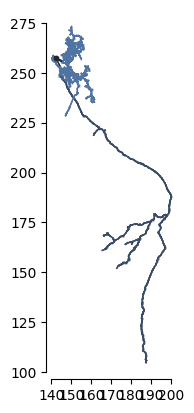

In [17]:
plot_neuron(neighbors, features)

In [65]:
for cell_id in tqdm(neuron_ids):
    print(f"Processing cell ID: {cell_id}")
    which_cell = neuron_ids.index(cell_id)

    path = Path('./skeletons/', str(cell_id))
    path.mkdir(parents=True, exist_ok=True)
    file_name = file_list[which_cell]
    print(f"Processing file: {file_name}")
    morphology = read_swc_file(file_name, correction=True)

    morphology['id'] = morphology['id'].astype(int)
    morphology['parent'] = morphology['parent'].astype(int)

    children_map = (morphology.loc[morphology['parent'] != -1]
                              .groupby('parent')['id']
                              .apply(list)
                              .to_dict())
    morphology['children'] = morphology['id'].apply(lambda _id: list(children_map.get(_id, [])))

    # Process graph.
    neighbors = {}
    idx2node = {}
    for i, item in enumerate(morphology.to_dict(orient='records')):
        sec_type = [0, 0, 0, 0]
        sec_type[item['type']] = 1
        feat = tuple([item['x'], item['y'], item['z'], item['radius']]) + tuple(sec_type)
        idx2node[i] = feat

        neighbors[i] = set(item['children'])
        if item['parent'] >= 0:
            neighbors[i].add(item['parent'])

    features = np.array(list(idx2node.values()))

    # Normalize soma position to origin (soma is row 0 after read_swc_file correction).
    soma_pos = features[0, :3]
    norm_features = features.copy()
    norm_features[:, :3] = norm_features[:, :3] - soma_pos

    # Test if graph is connected.
    adj_matrix = neighbors_to_adjacency(neighbors, range(len(neighbors)))
    G = nx.Graph(adj_matrix)
    if nx.number_connected_components(G) > 1:
        adj_matrix, neighbors = connect_graph(adj_matrix, neighbors, features)

    assert len(neighbors) == len(adj_matrix)
    assert len(neighbors) == len(norm_features)
    assert ~np.any(np.isnan(norm_features))

    np.save(Path(path, 'features'), norm_features)
    with open(Path(path, 'neighbors.pkl'), 'wb') as f:
        pickle.dump(dict(neighbors), f, pickle.HIGHEST_PROTOCOL)


  0%|          | 0/466 [00:00<?, ?it/s]

  0%|          | 1/466 [00:00<00:59,  7.82it/s]

Processing cell ID: 622848563
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_622848563_scale2_healed_syns_subsampled.swc
Processing cell ID: 413512420
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_413512420_scale2_healed_syns_subsampled.swc


  1%|          | 3/466 [00:00<01:02,  7.39it/s]

Processing cell ID: 401952559
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_401952559_scale2_healed_syns_subsampled.swc
Processing cell ID: 674872612
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_674872612_scale2_healed_syns_subsampled.swc


...

 99%|█████████▉| 463/466 [01:24<00:00,  5.92it/s]

Processing cell ID: 359307914
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_359307914_scale2_healed_syns_subsampled.swc
Processing cell ID: 140482381
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_140482381_scale2_healed_syns_subsampled.swc


100%|█████████▉| 465/466 [01:25<00:00,  5.86it/s]

Processing cell ID: 517400449
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_517400449_scale2_healed_syns_subsampled.swc
Processing cell ID: 192154374
Processing file: /nfs/data8/chuyu/data/20230422_160839/connectome/skeletons/healed_syns_swc/swc/subsampled_swcs/neuron_192154374_scale2_healed_syns_subsampled.swc


100%|██████████| 466/466 [01:25<00:00,  5.44it/s]


In [66]:
# save randomly 50 neurons id as validation set and the rest as training set (val_ids.npy and train_ids.npy)
import random
random.seed(42)
val_size = 50
val_ids = random.sample(neuron_ids, val_size)
train_ids = [nid for nid in neuron_ids if nid not in val_ids]
np.save('val_ids.npy', np.array(val_ids))
np.save('train_ids.npy', np.array(train_ids))


In [67]:
np.save('all_ids.npy', np.array(neuron_ids))